In [1]:
import sys
sys.path.append("../src")

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES, FocalLoss
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

Device: cuda
GPU name: NVIDIA GeForce RTX 3050


In [3]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [5]:
NUM_CLASSES = len(CLASSES)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print(model.fc)

Linear(in_features=2048, out_features=7, bias=True)


In [6]:
criterion = FocalLoss(alpha=class_weights_t, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7  # early stopping

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [8]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "resnet50_focal_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=1.3056 train_acc=0.2496 | val_loss=1.0289 val_acc=0.4528 | time=37.8s
Epoch 2/30 | train_loss=0.7206 train_acc=0.5931 | val_loss=0.6528 val_acc=0.6223 | time=30.2s
Epoch 3/30 | train_loss=0.5345 train_acc=0.6674 | val_loss=0.5567 val_acc=0.6683 | time=28.0s
Epoch 4/30 | train_loss=0.3724 train_acc=0.7535 | val_loss=0.5128 val_acc=0.6901 | time=27.5s
Epoch 5/30 | train_loss=0.3283 train_acc=0.7597 | val_loss=0.4762 val_acc=0.7264 | time=27.5s
Epoch 6/30 | train_loss=0.2949 train_acc=0.7878 | val_loss=0.4900 val_acc=0.7022 | time=26.0s
Epoch 7/30 | train_loss=0.2604 train_acc=0.8054 | val_loss=0.4663 val_acc=0.7167 | time=28.4s
Epoch 8/30 | train_loss=0.2426 train_acc=0.8173 | val_loss=0.4508 val_acc=0.7676 | time=28.3s
Epoch 9/30 | train_loss=0.2068 train_acc=0.8396 | val_loss=0.4531 val_acc=0.7482 | time=28.0s
Epoch 10/30 | train_loss=0.1711 train_acc=0.8682 | val_loss=0.4811 val_acc=0.7530 | time=28.1s
Epoch 11/30 | train_loss=0.1443 train_acc=0.8651 | val_loss

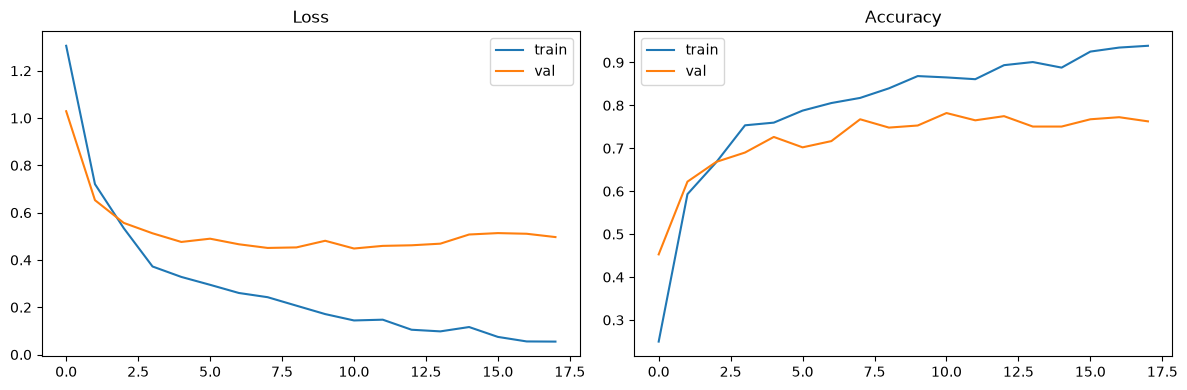

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7348251513591288
                 precision    recall  f1-score   support

        Healthy       0.80      0.92      0.86        90
         Insect       0.78      0.86      0.82        42
     Leaf Scald       0.74      0.71      0.73        63
     Rice Blast       0.90      0.78      0.84       105
Rice Leaffolder       0.67      0.81      0.73        37
   Rice Stripes       0.61      0.42      0.50        40
    Rice Tungro       0.66      0.69      0.68        36

       accuracy                           0.77       413
      macro avg       0.74      0.74      0.73       413
   weighted avg       0.77      0.77      0.77       413

Confusion matrix:
 [[83  2  0  3  0  1  1]
 [ 0 36  2  0  3  1  0]
 [ 0  1 45  1  9  2  5]
 [12  2  3 82  1  1  4]
 [ 1  2  1  1 30  2  0]
 [ 2  3  9  4  2 17  3]
 [ 6  0  1  0  0  4 25]]
